# Density-based clustering: Mean-Shift and DBSCAN

This notebook explores density-based clustering methods that do not require specifying the number of clusters in advance.

- **Mean-Shift** identifies clusters by finding high-density regions (modes).
- **DBSCAN** forms clusters based on density connectivity and can detect noise points.

# Setup

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import MeanShift, estimate_bandwidth, DBSCAN
from sklearn.preprocessing import StandardScaler

iris_df = pd.read_csv("./data/iris.csv")
mall_df = pd.read_csv("./data/Mall_Customers.csv", index_col="CustomerID")


# Iris (2D for visualization)
iris_features = ["petal_length", "petal_width"]
X_iris = iris_df[iris_features].values
X_iris = StandardScaler().fit_transform(X_iris)

# Mall
mall_features = ["Annual Income (k$)", "Spending Score (1-100)"]
X_mall = mall_df[mall_features].values
X_mall = StandardScaler().fit_transform(X_mall)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Mean-Shift - Iris

number of clusters is discovered automatically.

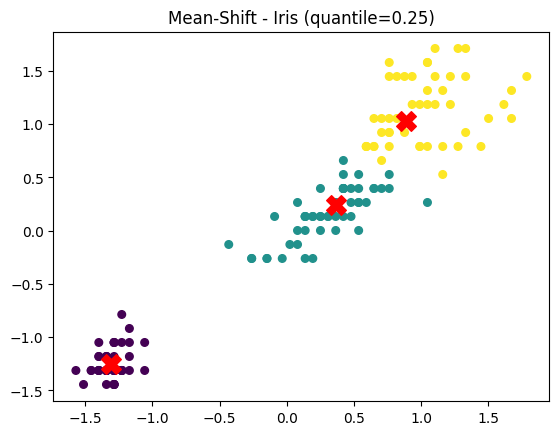

In [34]:
# change quantile param to see the difference
quantile=0.25
bandwidth = estimate_bandwidth(X_iris, quantile=quantile, n_samples=500)

ms = MeanShift(bandwidth=bandwidth)
labels = ms.fit_predict(X_iris)

plt.scatter(X_iris[:, 0], X_iris[:, 1], c=labels, s=30)
plt.scatter(ms.cluster_centers_[:, 0], ms.cluster_centers_[:, 1],
            c="red", s=200, marker="X")
plt.title(f"Mean-Shift - Iris (quantile={quantile})")
plt.show()

# Mean-Shift - Mall Customers

centers sit in high-density areas, not geometric centers

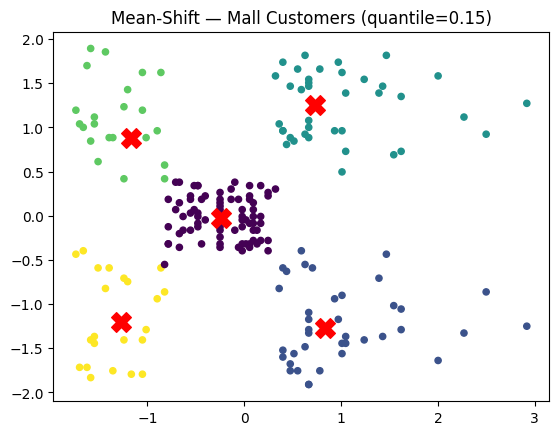

In [35]:
# change quantile param to see the difference
quantile=0.15
bandwidth = estimate_bandwidth(X_mall, quantile=quantile, n_samples=500)

ms = MeanShift(bandwidth=bandwidth)
labels = ms.fit_predict(X_mall)

plt.scatter(X_mall[:, 0], X_mall[:, 1], c=labels, s=20)
plt.scatter(ms.cluster_centers_[:, 0], ms.cluster_centers_[:, 1],
            c="red", s=200, marker="X")
plt.title(f"Mean-Shift — Mall Customers (quantile={quantile})")
plt.show()

# DBSCAN - Iris

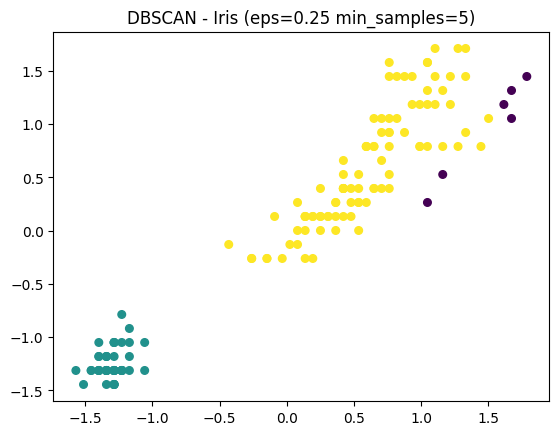

In [36]:
# change eps and min_samples params to see the difference
eps=0.25
min_samples=5
db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_iris)

plt.scatter(X_iris[:, 0], X_iris[:, 1], c=labels, s=30)
plt.title(f"DBSCAN - Iris (eps={eps} min_samples={min_samples})")
plt.show()

# DBSCAN - Mall Customers

- 4 clusters
- Some customers marked as noise - label -1 → noise points

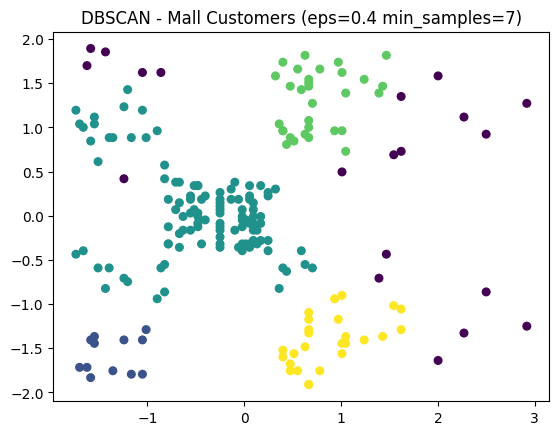

In [45]:
# change eps and min_samples params to see the difference
eps=0.4
min_samples=7
db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_mall)

plt.scatter(X_mall[:, 0], X_mall[:, 1], c=labels, s=30)
plt.title(f"DBSCAN - Mall Customers (eps={eps} min_samples={min_samples})")
plt.show()


# Differences vs K-Means
| Behavior         | K-Means | Mean-Shift | DBSCAN |
| ---------------- | ------- | ---------- | ------ |
| Requires K       | ✅       | ❌          | ❌      |
| Detects noise    | ❌       | ❌          | ✅      |
| Arbitrary shapes | ❌       | ✅          | ✅      |
| Density-based    | ❌       | ✅          | ✅      |


# Moons and circles datasets

In [46]:
from sklearn.datasets import make_moons, make_circles
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X_moons, _ = make_moons(n_samples=400, noise=0.08, random_state=42)
X_circles, _ = make_circles(n_samples=400, noise=0.05, factor=0.5, random_state=42)

X_moons = StandardScaler().fit_transform(X_moons)
X_circles = StandardScaler().fit_transform(X_circles)

## DBSCAN on moons

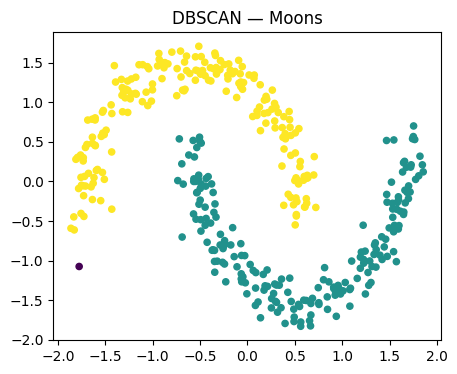

In [47]:
from sklearn.cluster import DBSCAN

db_moons = DBSCAN(eps=0.3, min_samples=5)
labels_moons = db_moons.fit_predict(X_moons)

plt.figure(figsize=(5, 4))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_moons, s=20)
plt.title("DBSCAN — Moons")
plt.show()

## K-Means on moon comparison

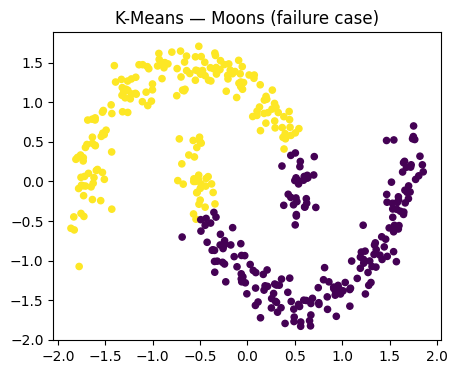

In [50]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_moons)

plt.figure(figsize=(5, 4))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=km_labels, s=20)
plt.title("K-Means — Moons (failure case)")
plt.show()

## DBSCAN on circles

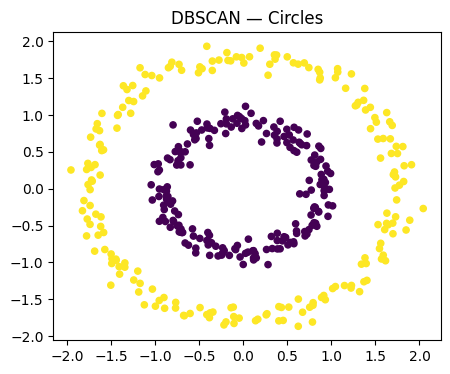

In [48]:
db_circles = DBSCAN(eps=0.3, min_samples=5)
labels_circles = db_circles.fit_predict(X_circles)

plt.figure(figsize=(5, 4))
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=labels_circles, s=20)
plt.title("DBSCAN — Circles")
plt.show()

## K-Means on circles comparison

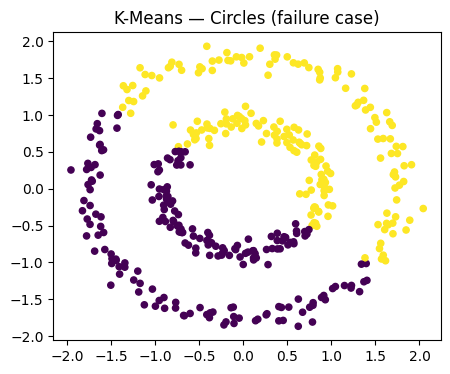

In [51]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_circles)

plt.figure(figsize=(5, 4))
plt.scatter(X_circles[:, 0], X_circles[:, 1], c=km_labels, s=20)
plt.title("K-Means — Circles (failure case)")
plt.show()